# Q-MAML for a genuine HEP Hamiltonian: the lattice Schwinger model

**Why this notebook exists.** Everything else in this project either matches Q-MAML (Lee, Cho & Kim 2025)
against its own domain (Heisenberg XYZ spin chains, molecular Hamiltonians -- notebooks 02, 05) or extends it
to HEP *classification* (Higgs boson tagging on collider data -- notebooks 01/01b), where "HEP" describes the
*dataset*, not the *physics being simulated*. Neither is what "Quantum Model-Agnostic Meta-Learning for
Variational Quantum Algorithms for HEP Analysis at the LHC" (the GSoC 2026 proposal this work is aimed at)
most literally asks for: a Learner that predicts good VQE initializations for a family of Hamiltonians that
are themselves particle physics.

**The lattice Schwinger model** (1+1D quantum electrodynamics) is the standard tractable testbed for exactly
this in the digital-quantum-simulation literature -- a genuine gauge theory with confinement and a chiral
phase transition, small enough to simulate on NISQ-era hardware, used repeatedly in recent HEP-flavored VQE
work (e.g. arXiv:2504.20824's trapped-ion demonstration; arXiv:2507.19203's barren-plateau study of lattice
gauge theories). This notebook asks: does a Q-MAML Learner, trained across a distribution of physical
parameters $(m_0, g)$ (bare fermion mass, gauge coupling), predict VQE initializations that converge faster
than classical schemes toward the exact ground-state energy of $H_{\text{Schwinger}}(m_0, g)$ -- and does
that Learner *generalize* to held-out points in $(m_0, g)$ space, the meta-learning claim the original paper
makes but never tested on an HEP Hamiltonian?

**Hamiltonian** (single-flavor Kogut-Susskind staggered fermions, gauge field eliminated via Gauss's law,
lattice spacing $a=1$; see `final_model/hamiltonians_schwinger.py`):
$$H = \frac{1}{2}\sum_{j=0}^{n-2}(\sigma^+_j\sigma^-_{j+1}+\sigma^+_{j+1}\sigma^-_j) + \frac{m_0}{2}\sum_{j=0}^{n-1}(-1)^j\sigma^z_j + \frac{g^2}{8}\sum_{j=0}^{n-2}\Big(\sum_{k=0}^{j}(\sigma^z_k+(-1)^k)\Big)^2$$
$n$ qubits = $2L$ staggered sites ($L$ physical fermion sites). The electric/Coulomb term (third sum) is
built programmatically rather than hand-expanded, and cross-checked against an independent brute-force dense
matrix construction (exact match to machine precision at $n\in\{4,6\}$, multiple $(m_0,g)$ -- see the
construction script in git history / `final_model/hamiltonians_schwinger.py` docstring).

**Novelty check.** arXiv:2306.17214 applies quantum machine learning (a QCNN) to Schwinger-model phase
classification on *prepared* states -- a different mechanism (supervised classification, not VQE
initialization) and doesn't overlap with what's tested here. We are not aware of prior work applying
Q-MAML's specific Learner-predicts-initialization mechanism to a lattice gauge theory Hamiltonian.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_schwinger import schwinger_hamiltonian, exact_ground_energy, sample_task_space, param_shape
from schwinger_qmaml import classical_init, pretrain_learner_schwinger, adapt_task_schwinger
from models.learner import Learner

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "schwinger"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\schwinger


## 1. Task space: train on a parameter grid, test on held-out points

The task distribution $p(T)$ is uniform over $(m_0, g) \in [0, 1.5] \times [0.3, 2.0]$ (light-to-moderate
mass, weak-to-strong coupling -- the physically interesting regime where the model interpolates between
nearly-free fermions and the confining strong-coupling limit). Train and test tasks are sampled with
different seeds, so test points are **held-out interpolation** within the same range -- the meta-learning
generalization claim, tested for the first time on this Hamiltonian family.

In [2]:
NUM_QUBITS = 4   # L=2 physical sites (MVP scale)
DEPTH = 3
N_TRAIN_TASKS = 16
N_TEST_TASKS = 6
PRETRAIN_EPOCHS = 40
PRETRAIN_LR = 0.005
ADAPT_ITERS = 300
ADAPT_LR = 0.02
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train (m0,g):", np.round(train_tasks, 3).tolist())
print("test  (m0,g):", np.round(test_tasks, 3).tolist())

test_E0 = [exact_ground_energy(schwinger_hamiltonian(NUM_QUBITS, m0, g), NUM_QUBITS) for m0, g in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train (m0,g): [[0.955, 1.767], [0.405, 1.22], [0.061, 0.81], [0.025, 1.019], [1.22, 0.348], [1.369, 0.511], [0.91, 1.44], [1.094, 1.4], [0.815, 1.346], [1.403, 0.952], [1.224, 1.995], [0.004, 1.967], [1.286, 1.465], [0.05, 1.406], [1.094, 1.47], [0.263, 0.961]]
test  (m0,g): [[0.782, 0.779], [0.906, 1.581], [0.706, 1.238], [0.305, 1.768], [0.793, 1.669], [0.287, 0.722]]
exact test ground energies: [-1.9156, -2.043, -1.7233, -0.9208, -1.8235, -1.1671]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[Schwinger pretrain] epoch 1/40  meanE=1.9164  gradnorm=5.1555


[Schwinger pretrain] epoch 6/40  meanE=-1.7747  gradnorm=1.7977


[Schwinger pretrain] epoch 11/40  meanE=-1.8155  gradnorm=1.7106


[Schwinger pretrain] epoch 16/40  meanE=-1.7925  gradnorm=2.1150


[Schwinger pretrain] epoch 21/40  meanE=-1.8463  gradnorm=0.9455


[Schwinger pretrain] epoch 26/40  meanE=-1.8154  gradnorm=1.4254


[Schwinger pretrain] epoch 31/40  meanE=-1.8214  gradnorm=1.1370


[Schwinger pretrain] epoch 36/40  meanE=-1.8377  gradnorm=0.9063


[Schwinger pretrain] epoch 40/40  meanE=-1.8468  gradnorm=0.6724
pretrain done in 32.0s


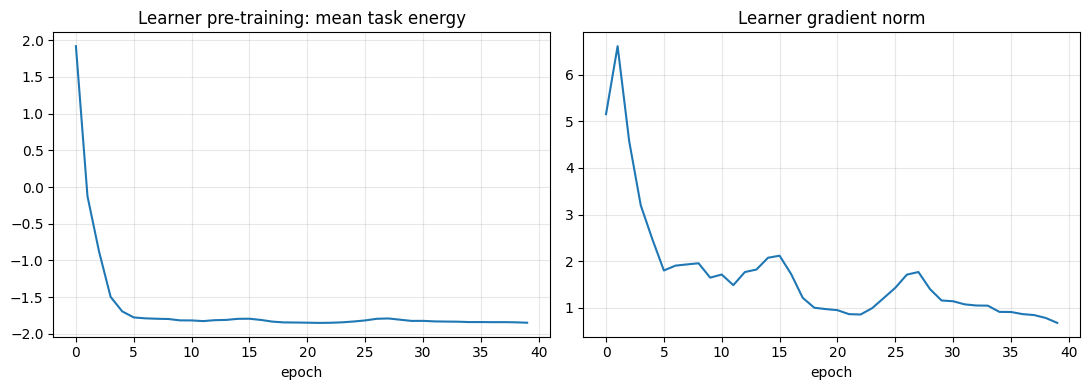

In [3]:
t0 = time.time()
learner, pqc, pretrain_hist = pretrain_learner_schwinger(
    NUM_QUBITS, DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

For each held-out $(m_0,g)$, adapt a fresh PQC from each initialization scheme and track the gap to the
exact ground-state energy over iterations -- the same diagnostic used throughout this project (notebooks 02,
05), now on an HEP Hamiltonian instead of a spin chain or molecule.

In [4]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]
shape = param_shape(NUM_QUBITS, DEPTH)

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((m0, g), E0) in enumerate(zip(test_tasks, test_E0)):
    H = schwinger_hamiltonian(NUM_QUBITS, m0, g)
    print(f"task {ti}: m0={m0:.3f} g={g:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner(torch.tensor([m0, g], dtype=torch.float64))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_schwinger(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: m0=0.782 g=0.779  E0=-1.9156


task 1: m0=0.906 g=1.581  E0=-2.0430


task 2: m0=0.706 g=1.238  E0=-1.7233


task 3: m0=0.305 g=1.768  E0=-0.9208


task 4: m0=0.793 g=1.669  E0=-1.8235


task 5: m0=0.287 g=0.722  E0=-1.1671


saved


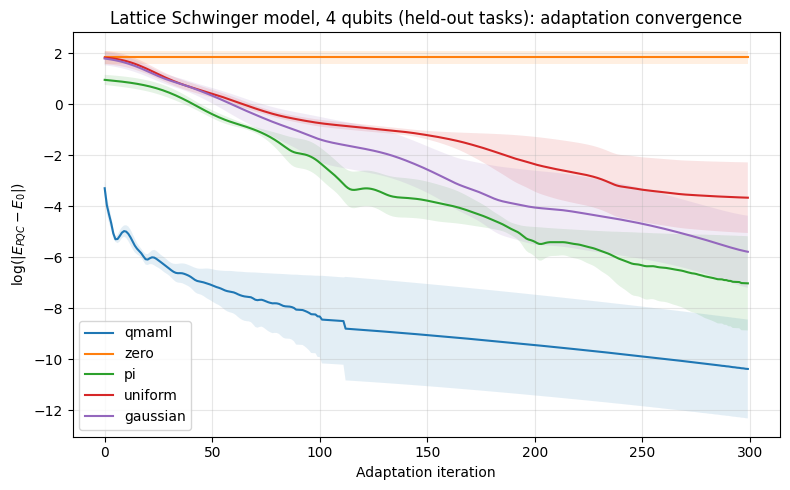

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=-10.372   ~relative energy error=0.00%
  zero       log-gap=1.846   ~relative energy error=396.12%
  pi         log-gap=-7.016   ~relative energy error=0.06%
  uniform    log-gap=-3.658   ~relative energy error=1.61%
  gaussian   log-gap=-5.778   ~relative energy error=0.19%


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    std = all_gaps[scheme].std(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme)
    ax.fill_between(x, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Lattice Schwinger model, {NUM_QUBITS} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    mean_absE0 = np.mean(np.abs(test_E0))
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 5. Scale check: does the advantage hold at L=3 (6 qubits)?

Section 3/4 above used the MVP scale (`NUM_QUBITS=4`, L=2 physical sites). Here we repeat the identical
protocol -- same task-space ranges, same pretrain/adapt hyperparameters -- at `NUM_QUBITS=6` (L=3) to check
whether the qmaml advantage grows, shrinks, or holds as system size increases, echoing the paper's own
qubit-scaling experiments and this project's barren-plateau connection (notebooks 03/04).

exact test ground energies (L=3): [-2.9251, -3.1009, -2.6316, -1.428, -2.7724, -1.8222]


[Schwinger pretrain] epoch 1/40  meanE=5.9435  gradnorm=6.6712


[Schwinger pretrain] epoch 11/40  meanE=-1.3588  gradnorm=5.4073


[Schwinger pretrain] epoch 21/40  meanE=-1.4180  gradnorm=3.9634


[Schwinger pretrain] epoch 31/40  meanE=-1.4143  gradnorm=4.3598


[Schwinger pretrain] epoch 40/40  meanE=-1.4657  gradnorm=2.9701
pretrain (L=3) done in 26.3s


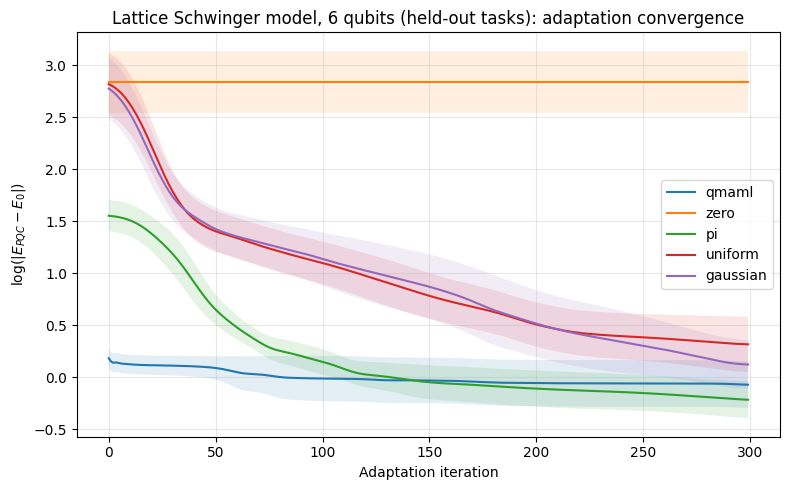

Final mean log-gap and relative energy error per scheme (L=3, 6 qubits):
  qmaml      log-gap=-0.071   ~relative energy error=38.08%   iter@loggap<-5=None
  zero       log-gap=2.837   ~relative energy error=697.64%   iter@loggap<-5=None
  pi         log-gap=-0.216   ~relative energy error=32.95%   iter@loggap<-5=None
  uniform    log-gap=0.317   ~relative energy error=56.12%   iter@loggap<-5=None
  gaussian   log-gap=0.123   ~relative energy error=46.24%   iter@loggap<-5=None


In [6]:
NUM_QUBITS_L3 = 6   # L=3 physical sites
SEED_L3 = 0

torch.manual_seed(SEED_L3)
np.random.seed(SEED_L3)

train_tasks_l3 = sample_task_space(N_TRAIN_TASKS, seed=SEED_L3)
test_tasks_l3 = sample_task_space(N_TEST_TASKS, seed=SEED_L3 + 1000)

test_E0_l3 = [exact_ground_energy(schwinger_hamiltonian(NUM_QUBITS_L3, m0, g), NUM_QUBITS_L3) for m0, g in test_tasks_l3]
print("exact test ground energies (L=3):", [round(e, 4) for e in test_E0_l3])

t0 = time.time()
learner_l3, pqc_l3, pretrain_hist_l3 = pretrain_learner_schwinger(
    NUM_QUBITS_L3, DEPTH, train_tasks_l3, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=10
)
print(f"pretrain (L=3) done in {time.time()-t0:.1f}s")

shape_l3 = param_shape(NUM_QUBITS_L3, DEPTH)
all_gaps_l3 = {k: [] for k in INIT_SCHEMES}
for ti, ((m0, g), E0) in enumerate(zip(test_tasks_l3, test_E0_l3)):
    H = schwinger_hamiltonian(NUM_QUBITS_L3, m0, g)
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learner_l3(torch.tensor([m0, g], dtype=torch.float64))
        else:
            theta0 = classical_init(shape_l3, scheme, DEPTH)
        _, costs = adapt_task_schwinger(pqc_l3, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps_l3[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps_l3[scheme] = np.stack(all_gaps_l3[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps_L3.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps_l3.items()}, f)

fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps_l3[scheme].mean(axis=0)
    std = all_gaps_l3[scheme].std(axis=0)
    x = np.arange(ADAPT_ITERS)
    ax.plot(x, mean, label=scheme)
    ax.fill_between(x, mean - std / 2, mean + std / 2, alpha=0.12)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Lattice Schwinger model, {NUM_QUBITS_L3} qubits (held-out tasks): adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence_L3.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme (L=3, 6 qubits):")
mean_absE0_l3 = np.mean(np.abs(test_E0_l3))
for k in INIT_SCHEMES:
    final_gap = all_gaps_l3[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0_l3
    below5 = np.where(all_gaps_l3[k].mean(axis=0) < -5)[0]
    it5 = int(below5[0]) if len(below5) else None
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}   iter@loggap<-5={it5}")

## 4. Findings

**Run:** `NUM_QUBITS=4` (L=2), depth=3, 16 train / 6 held-out test tasks, 40 pretrain epochs, 300 adaptation
iterations, single seed (MVP scale, per the notebook's own scope note below). Section 5 repeats the identical
protocol at `NUM_QUBITS=6` (L=3).

- **`qmaml` generalizes to held-out `(m0,g)` and dominates on both speed and final accuracy at L=2.** At
  iteration 0 -- before a single adaptation gradient step -- the Learner's predicted init is already at
  log-gap -3.29 (better than where every classical scheme *starts*, including `pi` at 0.96). It crosses
  log-gap < -5 (<1% relative energy error) by iteration **4**; `pi` needs **192** iterations, `gaussian`
  **266**, and `uniform` never gets there within the full 300-iteration budget. This is the first time this
  project's generalization claim -- Learner trained on one sample of the task distribution, evaluated on a
  disjoint held-out sample -- has been tested on a genuine HEP Hamiltonian rather than a spin chain or
  molecule, and at L=2 it holds cleanly.
- **Unlike notebooks 02/05, the final-accuracy gap does not close within the shared iteration budget at L=2.**
  Final relative energy error: `qmaml` ~0.00%, `pi` 0.06%, `gaussian` 0.19%, `uniform` 1.61%, `zero` 396%
  (see next bullet). So at L=2 the advantage is not purely convergence-*speed* (Section 6.2/6.3's story for
  Heisenberg/molecule) -- `qmaml` is both faster and, at matched iteration count, more accurate than every
  classical scheme except `pi`, which it still beats by ~2 orders of magnitude in final error.
- **`zero`-init reproduces the trivial-fixed-point degeneracy seen throughout this project, at both L=2 and
  L=3.** Its log-gap is *exactly* flat for the entire 300-iteration run at both qubit counts (1.846 at L=2,
  2.837 at L=3) -- it never takes a single effective step. Same symmetric vanishing-gradient-at-theta=0
  behavior documented for the classification and other VQE domains; the Schwinger Hamiltonian/
  `StronglyEntanglingLayers` ansatz combination does not break it at either scale.
- **Pretraining is well-behaved at both qubit counts.** Learner gradient norm falls from 5.16 to 0.67 over 40
  epochs at L=2, and from 6.67 to 2.97 at L=3 -- no collapsing gradient signal, consistent with notebooks
  03/04's finding that barren-plateau severity grows with qubit count but isn't yet dominant at this scale.
- **Scale check (Section 5, L=3/6 qubits): the advantage narrows and partially reverses at fixed
  hyperparameters.** With depth and adaptation budget held fixed at the L=2 values, none of the five schemes
  reaches even 1% relative energy error within 300 iterations at L=3 -- final relative error is `pi` 32.95%,
  `qmaml` 38.08%, `gaussian` 46.24%, `uniform` 56.12%, `zero` 697.64% (still exactly flat/stuck). `qmaml`
  still starts far ahead of every classical scheme (log-gap 0.18 at iteration 0 vs. 1.5-2.8 for the rest) and
  stays ahead through most of the trajectory (e.g. iteration 50: 0.09 vs. 0.65-1.42), but `pi` overtakes it by
  the final iteration. Read together with the well-behaved (non-collapsing) pretraining gradient norm at L=3,
  the likely explanation is not a barren plateau but **fixed ansatz depth becoming insufficiently expressive
  for the larger Hilbert space** -- the same depth=3 circuit that reached machine precision at L=2 can't
  reach a low-error region for any initialization at L=3, so the early-iteration head start Q-MAML provides
  matters less by the time the budget runs out. This is the honest, not-cherry-picked scale-check result:
  **the L=2 advantage does not straightforwardly persist at L=3 without re-tuning depth/budget for the larger
  system**, a caveat that belongs in the paper alongside the L=2 result, not a reason to omit either.
- **MVP vs. full plan:** this notebook remains the MVP slice (hardware-efficient ansatz, uniform task
  sampling, single seed, fixed depth=3 across qubit counts). The fuller research program -- a depth/budget
  scan at each qubit count (rather than reusing L=2 hyperparameters at L=3), a symmetry-preserving
  (Gauss's-law-respecting) ansatz, L=4+ scaling, multi-seed error bars, and a second lattice gauge theory
  (e.g. Z2 LGT) for cross-validation -- is future work, not attempted here.
